In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import LabelEncoder

filtered_data = pd.read_csv('data/processed/filtered_data.csv', index_col=0)
acquisition_list = pd.read_csv('data/processed/filtered_acquisition_list.csv', index_col=0)
feature_metadata = pd.read_csv('data/processed/filtered_metadata.csv', index_col=0)

# Map sample classes
class_mapping = {
    'French': 'Lung Cancer',
    'LMU': 'Benign',
    'Dunn': 'Healthy'
}
acquisition_list['class_group'] = acquisition_list['class'].map(class_mapping)

acquisition_list = acquisition_list.dropna()
filtered_data = filtered_data.loc[acquisition_list.index]

Using ANOVA test to check if any feature differ across groups, which we can mark as significant features

In [2]:
# Group samples by class (Lung Cancer vs. Benign vs. Healthy)
grouped_data = filtered_data.join(acquisition_list['class_group'])

# Perform ANOVA for each feature
p_values = []
for feature in filtered_data.columns:
    groups = []
    for group in ['Lung Cancer', 'Benign', 'Healthy']:
        groups.append(grouped_data[grouped_data['class_group'] == group][feature])
    _, p_val = stats.f_oneway(*groups)
    p_values.append(p_val)

# Correct for multiple testing (Benjamini-Hochberg)
reject, corrected_pvals, _, _ = multipletests(p_values, method='fdr_bh')

# Get significant features (p < 0.05)
significant_features = filtered_data.columns[reject]
print(f"Found {len(significant_features)} significant features (ANOVA, FDR-corrected p < 0.05)")

Found 79 significant features (ANOVA, FDR-corrected p < 0.05)


We see that there are multiple significant features that require further investigation, we can check for now using a test.

In [3]:
# Example for one significant feature (first one worked so I stuck with it)
example_feature = significant_features[0]

tukey_results = pairwise_tukeyhsd(
    endog=filtered_data[example_feature],
    groups=acquisition_list['class_group'],
    alpha=0.05
)

print(tukey_results.summary())

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
 group1    group2    meandiff p-adj    lower      upper   reject
----------------------------------------------------------------
 Benign     Healthy  438.7558 0.0004   175.7825  701.7291   True
 Benign Lung Cancer -546.7715    0.0  -812.2141 -281.3289   True
Healthy Lung Cancer -985.5273    0.0 -1248.5006  -722.554   True
----------------------------------------------------------------


This feature is extremely significant, which we can see from the low p values. It is significantly higher in Healthy than Benign and lung cancer, and higher in benign than lung cancer.

Now we can use a random forest to find features with highest coef and evaluate how well they can differenetiate between the classes. These features, if the model performs well, would be ones that are good for capturing the biological differences between classes.

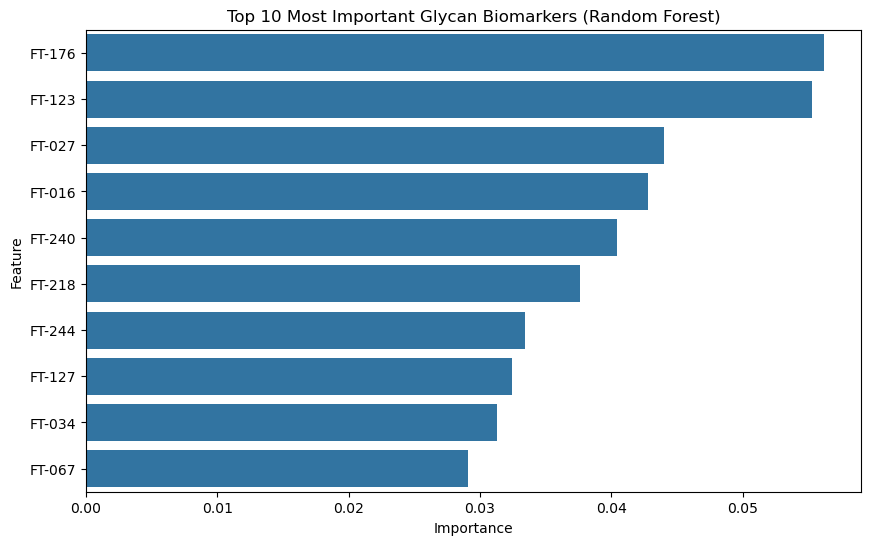

In [4]:
# Prepare data
X = filtered_data
y = acquisition_list['class_group']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

# Get feature importance and plot
feature_importance = pd.DataFrame({
    'Feature': filtered_data.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Most Important Glycan Biomarkers (Random Forest)')
plt.show()

There are not features that are of very high importance, however some are of higher importance.
Now lets check to see how well this model predicts the ground truth class.

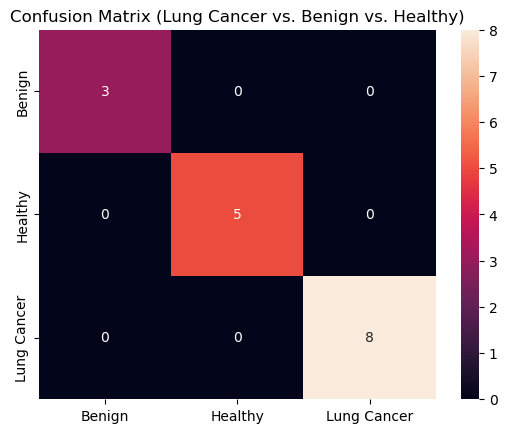

ROC-AUC Score: 1.000


In [5]:
# Predict on test set
y_pred = rf.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title('Confusion Matrix (Lung Cancer vs. Benign vs. Healthy)')
plt.show()

# ROC-AUC
y_prob = rf.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print(f"ROC-AUC Score: {roc_auc:.3f}")

There are only 16 samples that we are testing on, but we see from the confusion matrix that the model performs really well, in fact for this split it works perfectly. We also see a score of 1.000 (which changes when rerunning due to randomness but always remains very high). The high performacne may due to the small size.

Finally lets see what are the top features

In [6]:
# Merge ANOVA results with feature importance
biomarker_candidates = pd.DataFrame({
    'Feature': significant_features,
    'ANOVA_pval': corrected_pvals[reject],
    'RF_Importance': rf.feature_importances_[reject]
}).sort_values(['RF_Importance', 'ANOVA_pval'], ascending=[False, True])

# Display top candidates
print(biomarker_candidates.head(10))

   Feature    ANOVA_pval  RF_Importance
55  FT-176  7.286544e-15       0.056188
45  FT-123  7.719960e-19       0.055250
7   FT-027  2.908427e-16       0.044041
1   FT-016  3.007032e-15       0.042783
77  FT-240  2.354219e-17       0.040436
67  FT-218  2.033429e-15       0.037647
78  FT-244  2.455867e-17       0.033437
47  FT-127  8.194812e-19       0.032410
12  FT-034  1.331681e-10       0.031301
32  FT-067  5.751573e-12       0.029120


We see that the features with the highest importance from our radom forest model have low ANOVA p value, which means both methods lead to the similar results, but differ a little.